In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

from skimage.restoration import denoise_tv_chambolle
from scipy.ndimage import distance_transform_edt

In [2]:
rf = '/orcd/data/dvaron/001/kgauld/EMIT/results6/Retrievals'
rf_fix = '/orcd/data/dvaron/001/kgauld/EMIT/results6_destriped/Retrievals'

os.makedirs(rf_fix, exist_ok=True)

In [3]:
def get_destriped_field(field):
    mask = (field > np.nanpercentile(field, 90)).astype(np.uint8)
    mask2 = np.isnan(field)
    mask = np.clip(mask+mask2, 0, 1).astype(np.uint8)
    
    field_destriped = np.zeros_like(field)
    for row in range(len(field)):
        bg_pixels = field[row, mask[row, :] == 0]
        if len(bg_pixels) > 10:
            field_destriped[row, :] = field[row, :] - np.nanmedian(bg_pixels)
        else:
            field_destriped[row, :] = field[row, :]
    return field_destriped

In [4]:
loc_names = [k.split('/')[-1] for k in glob.glob(f"{rf}/*")]
loc_names

['Colstrip',
 'Ninemile_Point',
 'Labadie',
 'Gerald_Gentleman_Station',
 'W_A_Parish',
 'Belews_Creek',
 'Thomas_Hill_Energy_Center',
 'Intermountain',
 'Scherer',
 'Shawnee',
 'Limestone',
 'RIYADH_PLANT_9',
 'Mill_Creek',
 'Fort_Martin_Power_Station',
 'Alcoa_Allowance_Management_Inc',
 'Laramie_River',
 'Ghent',
 'Martin_Lake',
 'New_Madrid_Power_Plant']

In [5]:
for ln in loc_names:
    output_dir = f"{rf_fix}/{ln}"
    os.makedirs(output_dir, exist_ok=True)
    
    fns = [k.split('/')[-1] for k in glob.glob(f'{rf}/{ln}/*')]
    for f in fns:
        field = np.load(f"{rf}/{ln}/{f}")
        field_destriped = get_destriped_field(field)
        np.save(f"{rf_fix}/{ln}/{f}",field_destriped)

    print(f"Finished {ln}")

Finished Colstrip
Finished Ninemile_Point
Finished Labadie
Finished Gerald_Gentleman_Station


/home/kgauld/.conda/envs/nox_env_2/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Finished W_A_Parish
Finished Belews_Creek
Finished Thomas_Hill_Energy_Center
Finished Intermountain
Finished Scherer
Finished Shawnee
Finished Limestone
Finished RIYADH_PLANT_9
Finished Mill_Creek
Finished Fort_Martin_Power_Station
Finished Alcoa_Allowance_Management_Inc
Finished Laramie_River
Finished Ghent
Finished Martin_Lake
Finished New_Madrid_Power_Plant


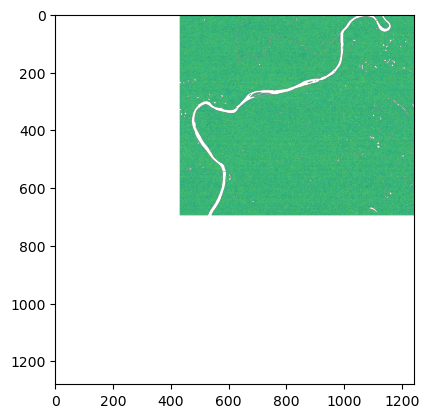

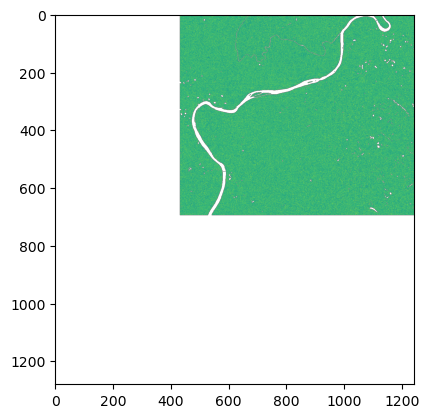

In [31]:
plt.imshow(field)
plt.show()
plt.imshow(field_destriped)
plt.show()

In [40]:
def get_tvfilt(field):
    mask =  np.isnan(field)
    scale = np.nanmax(field)
    
    _, idx = distance_transform_edt(mask, return_indices=True)
    filled = field[tuple(idx)]/scale   # copies nearest valid value into each NaN pixel
    
    tv = denoise_tv_chambolle(filled, weight=0.2)*scale
    tv[mask] = np.nan

    print(np.nanmax(tv),np.nanmin(tv))
    return tv

0.017239702943151726 -0.015059010051518603


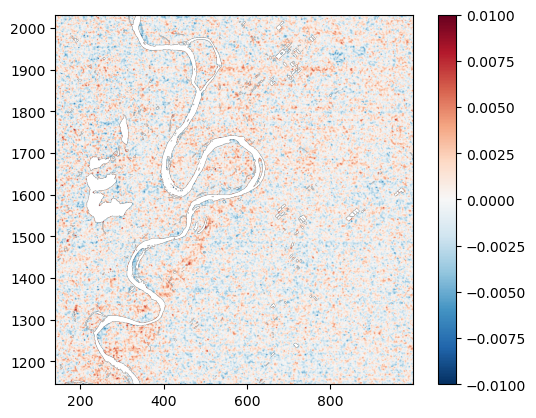

0.016903294176350385 -0.012448825751060901


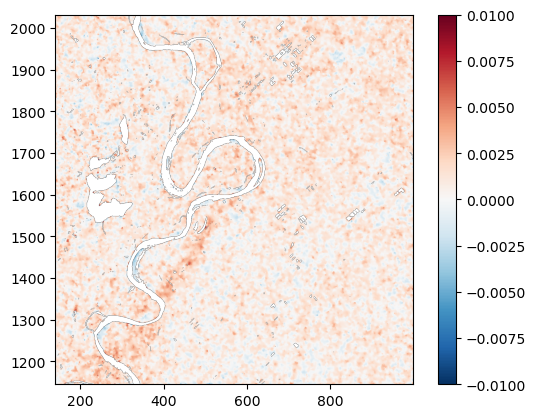

In [50]:
nm_fn = '/orcd/data/dvaron/001/kgauld/EMIT/results7/Retrievals/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20241201T171748_2433612_030.npy'
field = np.load(nm_fn)
field_destriped = get_destriped_field(field)

ftv=get_tvfilt(field)
nb = np.where(~np.isnan(ftv))

plt.imshow(ftv, cmap='RdBu_r', vmin=-1e-2, vmax=1e-2)
plt.xlim(nb[1].min(), nb[1].max()); plt.ylim(nb[0].min(), nb[0].max())
plt.colorbar()
plt.show()

ftv=get_tvfilt(field_destriped)
plt.imshow(ftv, cmap='RdBu_r', vmin=-1e-2, vmax=1e-2)
plt.xlim(nb[1].min(), nb[1].max()); plt.ylim(nb[0].min(), nb[0].max())
plt.colorbar()
plt.show()